In [1]:
import os
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# еще сеточки подкючить

In [24]:
DATA_FILE = 'data/'
TEST_FILE, TRAIN_FILE = '', ''

In [26]:
def load_data(filename):
    filepath = DATA_FILE + filename
    df = pd.read_csv(filepath)
    feature_column = ["id", "breed"]
    df['image_path'] = df["id"].apply(
        lambda id: os.path.join(TRAIN_FILE, "train", f"{id}.jpg")
    )
    return df

In [27]:
labels = load_data("labels.csv")
labels.head()

,id,breed,image_path
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull,train\000bec180eb18c7604dcecc8fe0dba07.jpg
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo,train\001513dfcb2ffafc82cccf4d8bbaba97.jpg
2,001cdf01b096e06d78e9e5112d419397,pekinese,train\001cdf01b096e06d78e9e5112d419397.jpg
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick,train\00214f311d5d2247d5dfe4fe24b2303d.jpg
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever,train\0021f9ceb3235effd7fcde7f7538ed62.jpg


In [30]:
if labels.duplicated().sum() != 0:
    print("че-то не так, дата дублируется")

In [31]:
labels["breed"].value_counts().head(10)

breed
scottish_deerhound      126
maltese_dog             117
afghan_hound            116
entlebucher             115
bernese_mountain_dog    114
shih-tzu                112
great_pyrenees          111
pomeranian              111
basenji                 110
samoyed                 109
Name: count, dtype: int64

In [32]:
labels["breed"].value_counts().tail(10)

breed
walker_hound         69
german_shepherd      69
otterhound           69
giant_schnauzer      69
tibetan_mastiff      69
golden_retriever     67
komondor             67
brabancon_griffon    67
eskimo_dog           66
briard               66
Name: count, dtype: int64

In [15]:
labels["breed"].value_counts().median()

np.float64(82.0)

Text(0.5, 1.0, 'Tibetan Mastiff')

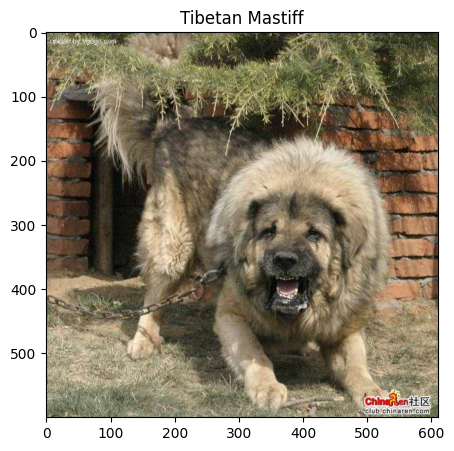

In [21]:
plt.figure(figsize = (12, 5))
plt.imshow(
    plt.imread(labels.loc[9000, "image_path"]) / 255.0
)
plt.title(" ".join(labels.loc[9000, "breed"].split("_")).title())
